In [1]:
!pip install transformers torch pandas numpy scikit-learn itables matplotlib scipy optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.1 MB/s eta 0:00:00


In [1]:
import copy
import io
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from itables import show
from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from google.colab import drive, files

    drive.mount("/content/drive")
    folder_path = "/content/drive/MyDrive/my_data_folder/"
except ImportError:
    folder_path = "./processed_data"

In [3]:
TUNING_DIR = "nn_output/tuning"
os.makedirs(TUNING_DIR, exist_ok=True)

X_train_path = os.path.join(folder_path, "X_train.csv")
X_test_path = os.path.join(folder_path, "X_test.csv")
X_val_path = os.path.join(folder_path, "X_val.csv")
y_train_path = os.path.join(folder_path, "y_train.csv")
y_test_path = os.path.join(folder_path, "y_test.csv")
y_val_path = os.path.join(folder_path, "y_val.csv")

E1_train_path = os.path.join(folder_path, "E1_train.npy")
E2_train_path = os.path.join(folder_path, "E2_train.npy")
E1_test_path = os.path.join(folder_path, "E1_test.npy")
E2_test_path = os.path.join(folder_path, "E2_test.npy")
E1_val_path = os.path.join(folder_path, "E1_val.npy")
E2_val_path = os.path.join(folder_path, "E2_val.npy")

print(f"Data paths set. Checking if files exist...")
all_file_paths = [
    X_train_path,
    X_test_path,
    X_val_path,
    y_train_path,
    y_test_path,
    y_val_path,
    E1_train_path,
    E2_train_path,
    E1_test_path,
    E2_test_path,
    E1_val_path,
    E2_val_path,
]
for f in all_file_paths:
    print(f"{f}: {'Found' if os.path.exists(f) else 'Not Found'}")

Data paths set. Checking if files exist...
./processed_data\X_train.csv: Found
./processed_data\X_test.csv: Found
./processed_data\X_val.csv: Found
./processed_data\y_train.csv: Found
./processed_data\y_test.csv: Found
./processed_data\y_val.csv: Found
./processed_data\E1_train.npy: Found
./processed_data\E2_train.npy: Found
./processed_data\E1_test.npy: Found
./processed_data\E2_test.npy: Found
./processed_data\E1_val.npy: Found
./processed_data\E2_val.npy: Found


In [4]:
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(101)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_VARIABLE = "Mole fraction"

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# X_train = pd.read_csv("X_train.csv")
# X_test = pd.read_csv("X_test.csv")
# X_val = pd.read_csv("X_val.csv")
# y_train = pd.read_csv("y_train.csv")
# y_test = pd.read_csv("y_test.csv")
# y_val = pd.read_csv("y_val.csv")

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
X_val = pd.read_csv(X_val_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)
y_val = pd.read_csv(y_val_path)

In [7]:
X_train.drop(columns=["Component 1", "Component 2", "mol1", "mol2"], inplace=True)
X_test.drop(columns=["Component 1", "Component 2", "mol1", "mol2"], inplace=True)
X_val.drop(columns=["Component 1", "Component 2", "mol1", "mol2"], inplace=True)

In [8]:
# show(X_train.head())

In [9]:
X_train.columns.get_loc("('BalabanJ', <class 'numpy.float64'>)")
X_train.columns.get_loc("('BalabanJ', <class 'numpy.float64'>).1")

205

In [10]:
def separate_features(X):
    return (
        X.iloc[:, 0:3],
        X.iloc[:, 3:5],
        X.iloc[:, 5:205],
        X.iloc[:, 205:405],
        X.iloc[:, 405:430],
        X.iloc[:, 430:],
    )


# property_T_P, SMILES, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [11]:
(
    X_train_prop,
    X_train_smiles,
    X_train_comp1_desc,
    X_train_comp2_desc,
    X_train_prop_cat,
    X_train_phase,
) = separate_features(X_train)
(
    X_test_prop,
    X_test_smiles,
    X_test_comp1_desc,
    X_test_comp2_desc,
    X_test_prop_cat,
    X_test_phase,
) = separate_features(X_test)
(
    X_val_prop,
    X_val_smiles,
    X_val_comp1_desc,
    X_val_comp2_desc,
    X_val_prop_cat,
    X_val_phase,
) = separate_features(X_val)

In [12]:
# show(X_train_phase.head())

In [13]:
# E1_train = np.load("E1_train.npy")
# E2_train = np.load("E2_train.npy")
# E1_test = np.load("E1_test.npy")
# E2_test = np.load("E2_test.npy")
# E1_val = np.load("E1_val.npy")
# E2_val = np.load("E2_val.npy")
E1_train = np.load(E1_train_path)
E2_train = np.load(E2_train_path)
E1_test = np.load(E1_test_path)
E2_test = np.load(E2_test_path)
E1_val = np.load(E1_val_path)
E2_val = np.load(E2_val_path)

scaler_smiles = StandardScaler()  # add this
scaler_smiles.fit(np.concatenate([E1_train, E2_train], axis=0))

# Transform all using the same scaler
E1_train = scaler_smiles.transform(E1_train)
E2_train = scaler_smiles.transform(E2_train)
E1_val = scaler_smiles.transform(E1_val)
E2_val = scaler_smiles.transform(E2_val)
E1_test = scaler_smiles.transform(E1_test)
E2_test = scaler_smiles.transform(E2_test)

In [14]:
class RDKitEncoder(nn.Module):
    def __init__(self, input_dim=200, embed_dim=128, dropout=0.2, use_layer_norm=True):
        super().__init__()
        norm1 = nn.LayerNorm(256) if use_layer_norm else nn.BatchNorm1d(256)
        norm2 = nn.LayerNorm(embed_dim) if use_layer_norm else nn.BatchNorm1d(embed_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            norm1,
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, embed_dim),
            norm2,
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [15]:
class MixtureFusion(nn.Module):
    DIM_MULTIPLIERS = {"origin": 2, "prod": 1, "sum": 1, "cos": 0}

    def __init__(self, dim, mix_str_list=("origin", "prod", "sum", "cos")):
        super().__init__()
        self.str_list = mix_str_list
        input_dim = sum(
            (self.DIM_MULTIPLIERS[s] * dim if self.DIM_MULTIPLIERS[s] > 0 else 1)
            for s in mix_str_list
        )
        self.linear = nn.Linear(input_dim, dim)

    @staticmethod
    def prod(x1, x2):
        return x1 * x2

    @staticmethod
    def sum(x1, x2):
        return x1 + x2

    @staticmethod
    def origin(x1, x2):
        return torch.cat([x1, x2], dim=-1)

    @staticmethod
    def cos(x1, x2):
        return torch.nn.functional.cosine_similarity(x1, x2, dim=-1).unsqueeze(-1)

    def forward(self, x1, x2):
        parts = [getattr(self, s)(x1, x2) for s in self.str_list]
        return self.linear(torch.cat(parts, dim=-1))

In [16]:
class MultiModalNet(nn.Module):
    def __init__(
        self,
        smiles_dim=512,  # SMOLE-BERT output dim
        rdkit_dim=200,  # RDKit features per component
        rdkit_embed_dim=128,  # RDKit encoder output dim
        tabular_dim=30,  # T, P, physics features
        fusion_dim=256,  # projection dim for SMILES fusion
        hidden_dim=256,
        n_predictor_layers=3,  # number of hidden layers in predictor MLP
        dropout=0.2,
        use_layer_norm=True,
    ):
        super().__init__()
        self.use_layer_norm = use_layer_norm

        # SMILES projection + fusion
        self.smiles_proj = nn.Linear(smiles_dim, fusion_dim)
        self.smiles_fusion = MixtureFusion(fusion_dim)

        # RDKit encoder (shared) + fusion
        self.rdkit_enc = RDKitEncoder(
            input_dim=rdkit_dim,
            embed_dim=rdkit_embed_dim,
            dropout=dropout,
            use_layer_norm=use_layer_norm,
        )
        self.rdkit_fusion = MixtureFusion(rdkit_embed_dim)

        # Predictor MLP: n_predictor_layers hidden layers of hidden_dim with ReLU + Dropout,
        # followed by a linear output layer. Input and output layers have no activation/dropout.
        combined_dim = fusion_dim + rdkit_embed_dim + tabular_dim
        layers = []
        in_dim = combined_dim
        for _ in range(n_predictor_layers):
            layers.extend(self._mlp_block(in_dim, hidden_dim, dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 1))
        layers.append(nn.Hardtanh(min_val=0.0, max_val=1.0))
        self.predictor = nn.Sequential(*layers)

    def _mlp_block(self, in_dim, out_dim, dropout):
        norm = nn.LayerNorm(out_dim) if self.use_layer_norm else nn.BatchNorm1d(out_dim)
        return [nn.Linear(in_dim, out_dim), norm, nn.ReLU(), nn.Dropout(dropout)]

    def forward(self, smiles_e1, smiles_e2, rdkit_x1, rdkit_x2, tabular):
        # SMILES stream
        e1 = self.smiles_proj(smiles_e1.float())
        e2 = self.smiles_proj(smiles_e2.float())
        s = self.smiles_fusion(e1, e2)

        # RDKit stream
        r1 = self.rdkit_enc(rdkit_x1.float())
        r2 = self.rdkit_enc(rdkit_x2.float())
        x = self.rdkit_fusion(r1, r2)

        # Concatenate all streams + tabular
        fused = torch.cat([s, x, tabular.float()], dim=-1)

        return self.predictor(fused)

In [17]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    n_epochs=300,
    scheduler=None,
    save_path="best_model.pth",
    plot_curves=True,
    plot_save_path="training_curves.png",
    device=None,
    verbose_interval=10,
):
    if device is None:
        device = next(model.parameters()).device

    print(f"Training on {device}")
    model.to(device)
    best_val_loss = float("inf")
    best_epoch = -1
    train_loss_history = []
    val_loss_history = []

    for epoch in range(n_epochs):
        # --- Train ---
        model.train()
        train_losses = []
        for E1, E2, X1, X2, tab, y_batch in train_loader:
            E1, E2, X1, X2, tab, y_batch = [
                t.to(device) for t in [E1, E2, X1, X2, tab, y_batch]
            ]
            optimizer.zero_grad()
            pred = model(E1, E2, X1, X2, tab).squeeze()
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validate ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for E1, E2, X1, X2, tab, y_batch in val_loader:
                E1, E2, X1, X2, tab, y_batch = [
                    t.to(device) for t in [E1, E2, X1, X2, tab, y_batch]
                ]
                pred = model(E1, E2, X1, X2, tab).squeeze()
                val_losses.append(criterion(pred, y_batch).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        # Save best model checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                },
                save_path,
            )

        if verbose_interval and (epoch + 1) % verbose_interval == 0:
            print(
                f"Epoch {epoch+1}/{n_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best Val: {best_val_loss:.4f} (epoch {best_epoch})"
            )

    # Restore best weights
    checkpoint = torch.load(save_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(
        f"\nTraining complete. Best val loss: {best_val_loss:.4f} at epoch {best_epoch}."
    )

    if plot_curves:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(train_loss_history, label="Train")
        ax.plot(val_loss_history, label="Val")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title("Training Curves")
        ax.legend()
        fig.tight_layout()
        if plot_save_path:
            fig.savefig(plot_save_path, dpi=150)
        plt.show()

    return train_loss_history, val_loss_history, best_val_loss, model

In [18]:
# Tabular: scale and concatenate prop + prop_cat + phase
# Scale only continuous part (T, P, Physics value)
scaler_tab = StandardScaler()
prop_train_scaled = scaler_tab.fit_transform(X_train_prop)
prop_val_scaled = scaler_tab.transform(X_val_prop)
prop_test_scaled = scaler_tab.transform(X_test_prop)

# Concatenate with unscaled one-hot columns
tabular_train = np.concatenate(
    [prop_train_scaled, X_train_prop_cat, X_train_phase], axis=1
)
tabular_val = np.concatenate([prop_val_scaled, X_val_prop_cat, X_val_phase], axis=1)
tabular_test = np.concatenate([prop_test_scaled, X_test_prop_cat, X_test_phase], axis=1)

In [19]:
class MultiModalDataset(Dataset):
    def __init__(self, E1, E2, X1, X2, tabular, y):
        self.E1 = torch.tensor(E1, dtype=torch.float32)
        self.E2 = torch.tensor(E2, dtype=torch.float32)
        self.X1 = torch.tensor(np.array(X1), dtype=torch.float32)
        self.X2 = torch.tensor(np.array(X2), dtype=torch.float32)
        self.tabular = torch.tensor(np.array(tabular), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32).squeeze()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.E1[idx],
            self.E2[idx],
            self.X1[idx],
            self.X2[idx],
            self.tabular[idx],
            self.y[idx],
        )

In [20]:
X1_train, X2_train = X_train_comp1_desc, X_train_comp2_desc
X1_val, X2_val = X_val_comp1_desc, X_val_comp2_desc
X1_test, X2_test = X_test_comp1_desc, X_test_comp2_desc

train_dataset = MultiModalDataset(
    E1_train, E2_train, X1_train, X2_train, tabular_train, y_train
)
val_dataset = MultiModalDataset(E1_val, E2_val, X1_val, X2_val, tabular_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    generator=g,
    worker_init_fn=lambda worker_id: np.random.seed(101 + worker_id),
)
val_loader = DataLoader(val_dataset, batch_size=512)

In [28]:
model = MultiModalNet(dropout=0.1)
# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-04)
train_loss_history, val_loss_history, best_val_loss, best_model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    save_path="./nn_output/multimodel_best_l1.pth",
    plot_save_path="./nn_output/multimodel_best_l1.png",
    device=torch.device("cuda:0"),
)

NameError: name 'train_model' is not defined

Training on cuda:0
Epoch 10/300 | Train: 0.0366 | Val: 0.0320 | Best Val: 0.0320 (epoch 10)
Epoch 20/300 | Train: 0.0271 | Val: 0.0254 | Best Val: 0.0254 (epoch 19)
Epoch 30/300 | Train: 0.0253 | Val: 0.0233 | Best Val: 0.0230 (epoch 29)
Epoch 40/300 | Train: 0.0241 | Val: 0.0228 | Best Val: 0.0228 (epoch 40)
Epoch 50/300 | Train: 0.0236 | Val: 0.0235 | Best Val: 0.0214 (epoch 48)
Epoch 60/300 | Train: 0.0227 | Val: 0.0214 | Best Val: 0.0211 (epoch 59)
Epoch 70/300 | Train: 0.0220 | Val: 0.0206 | Best Val: 0.0206 (epoch 65)
Epoch 80/300 | Train: 0.0217 | Val: 0.0217 | Best Val: 0.0204 (epoch 71)
Epoch 90/300 | Train: 0.0217 | Val: 0.0208 | Best Val: 0.0201 (epoch 85)
Epoch 100/300 | Train: 0.0209 | Val: 0.0205 | Best Val: 0.0201 (epoch 85)
Epoch 110/300 | Train: 0.0208 | Val: 0.0200 | Best Val: 0.0197 (epoch 101)
Epoch 120/300 | Train: 0.0208 | Val: 0.0203 | Best Val: 0.0195 (epoch 112)
Epoch 130/300 | Train: 0.0205 | Val: 0.0195 | Best Val: 0.0192 (epoch 123)
Epoch 140/300 | Train: 0.

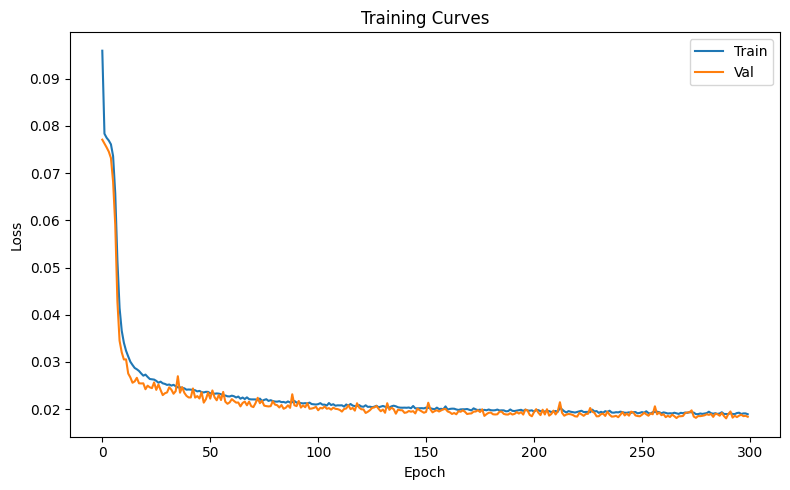

In [30]:
model = MultiModalNet(dropout=0.1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-04)
train_loss_history2, val_loss_history2, best_val_loss2, best_model2 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    save_path="./nn_output/multimodel_best_mse.pth",
    plot_save_path="./nn_output/multimodel_best_mse.png",
    device=torch.device("cuda:0"),
)

In [29]:
MIX_OPTIONS = ("origin", "prod", "sum", "cos")


def objective(trial):
    # Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    n_predictor_layers = trial.suggest_int("n_predictor_layers", 1, 5)
    rdkit_embed = trial.suggest_categorical("rdkit_embed_dim", [64, 128, 256])
    fusion_dim = trial.suggest_categorical("fusion_dim", [128, 256, 512])

    # mix_str_list: independently sample each fusion op; guarantee at least one
    use_flags = {
        op: trial.suggest_categorical(f"mix_{op}", [True, False]) for op in MIX_OPTIONS
    }
    mix_str_list = [op for op, flag in use_flags.items() if flag] or ["origin"]

    model = MultiModalNet(
        smiles_dim=512,
        rdkit_dim=200,
        rdkit_embed_dim=rdkit_embed,
        tabular_dim=tabular_train.shape[1],
        fusion_dim=fusion_dim,
        hidden_dim=hidden_dim,
        n_predictor_layers=n_predictor_layers,
        dropout=dropout,
    ).to(device)
    model.smiles_fusion = MixtureFusion(fusion_dim, mix_str_list=mix_str_list).to(
        device
    )
    model.rdkit_fusion = MixtureFusion(rdkit_embed, mix_str_list=mix_str_list).to(
        device
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    for epoch in range(50):
        model.train()
        for E1, E2, X1, X2, tab, y_batch in train_loader:
            E1, E2, X1, X2, tab, y_batch = [
                t.to(device) for t in [E1, E2, X1, X2, tab, y_batch]
            ]
            optimizer.zero_grad()
            loss = criterion(model(E1, E2, X1, X2, tab).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_losses = [
                criterion(
                    model(
                        E1.to(device),
                        E2.to(device),
                        X1.to(device),
                        X2.to(device),
                        tab.to(device),
                    ).squeeze(),
                    y_batch.to(device),
                ).item()
                for E1, E2, X1, X2, tab, y_batch in val_loader
            ]
        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best val MSE:", study.best_value)

# Save tuning results
best_mix = [op for op in MIX_OPTIONS if study.best_params.get(f"mix_{op}", False)] or [
    "origin"
]
tuning_results = {
    "best_value": study.best_value,
    "best_params": study.best_params,
    "best_mix_str_list": best_mix,
    "trials": [
        {
            "number": t.number,
            "value": t.value,
            "params": t.params,
            "state": str(t.state),
        }
        for t in study.trials
    ],
}
with open(os.path.join(TUNING_DIR, "tuning_results.json"), "w") as f:
    json.dump(tuning_results, f, indent=2)
print(f"Tuning results saved to {TUNING_DIR}/tuning_results.json")

[I 2026-04-09 12:34:04,534] A new study created in memory with name: no-name-01076a61-80de-4732-a290-2a69185ccb6b
  0%|          | 0/100 [00:01<?, ?it/s]

[W 2026-04-09 12:34:06,498] Trial 0 failed with parameters: {'lr': 2.714408915644803e-05, 'dropout': 0.1872767016161022, 'hidden_dim': 256, 'n_predictor_layers': 1, 'rdkit_embed_dim': 128, 'fusion_dim': 256, 'mix_origin': False, 'mix_prod': False, 'mix_sum': False, 'mix_cos': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\admin\Desktop\CHE1148-VLE-Project\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\admin\AppData\Local\Temp\ipykernel_42788\3900674379.py", line 53, in objective
    for E1, E2, X1, X2, tab, y_batch in val_loader
                                        ^^^^^^^^^^
  File "C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py", line 732, in __next__
    data = self._next_data()
  File "C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py", line 788, in

KeyboardInterrupt: 

Training on cuda
Epoch 10/300 | Train: 0.0312 | Val: 0.0285 | Best Val: 0.0285 (epoch 10)
Epoch 20/300 | Train: 0.0270 | Val: 0.0254 | Best Val: 0.0253 (epoch 19)
Epoch 30/300 | Train: 0.0257 | Val: 0.0256 | Best Val: 0.0243 (epoch 28)
Epoch 40/300 | Train: 0.0247 | Val: 0.0239 | Best Val: 0.0230 (epoch 38)
Epoch 50/300 | Train: 0.0237 | Val: 0.0236 | Best Val: 0.0227 (epoch 48)
Epoch 60/300 | Train: 0.0219 | Val: 0.0208 | Best Val: 0.0208 (epoch 60)
Epoch 70/300 | Train: 0.0213 | Val: 0.0203 | Best Val: 0.0203 (epoch 70)
Epoch 80/300 | Train: 0.0201 | Val: 0.0194 | Best Val: 0.0194 (epoch 80)
Epoch 90/300 | Train: 0.0201 | Val: 0.0194 | Best Val: 0.0190 (epoch 87)
Epoch 100/300 | Train: 0.0193 | Val: 0.0189 | Best Val: 0.0187 (epoch 98)
Epoch 110/300 | Train: 0.0192 | Val: 0.0186 | Best Val: 0.0186 (epoch 110)
Epoch 120/300 | Train: 0.0187 | Val: 0.0186 | Best Val: 0.0185 (epoch 119)
Epoch 130/300 | Train: 0.0187 | Val: 0.0184 | Best Val: 0.0183 (epoch 125)
Epoch 140/300 | Train: 0.01

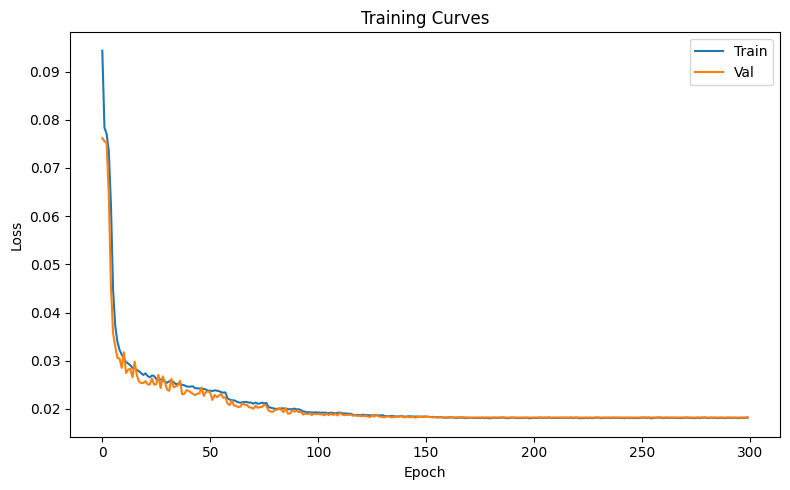

In [45]:
best_params = study.best_params

best_mix_str_list = [
    op for op in MIX_OPTIONS if best_params.get(f"mix_{op}", False)
] or ["origin"]

best_model = MultiModalNet(
    smiles_dim=512,
    rdkit_dim=200,
    rdkit_embed_dim=best_params["rdkit_embed_dim"],
    tabular_dim=tabular_train.shape[1],
    fusion_dim=best_params["fusion_dim"],
    hidden_dim=best_params["hidden_dim"],
    n_predictor_layers=best_params["n_predictor_layers"],
    dropout=best_params["dropout"],
).to(device)
best_model.smiles_fusion = MixtureFusion(
    best_params["fusion_dim"], mix_str_list=best_mix_str_list
).to(device)
best_model.rdkit_fusion = MixtureFusion(
    best_params["rdkit_embed_dim"], mix_str_list=best_mix_str_list
).to(device)

optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

train_loss_history, val_loss_history, best_val_loss, best_model = train_model(
    model=best_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    n_epochs=300,
    scheduler=scheduler,
    save_path=os.path.join(TUNING_DIR, "best_model.pth"),
    plot_curves=True,
    plot_save_path=os.path.join(TUNING_DIR, "training_curves.png"),
    device=device,
    verbose_interval=10,
)

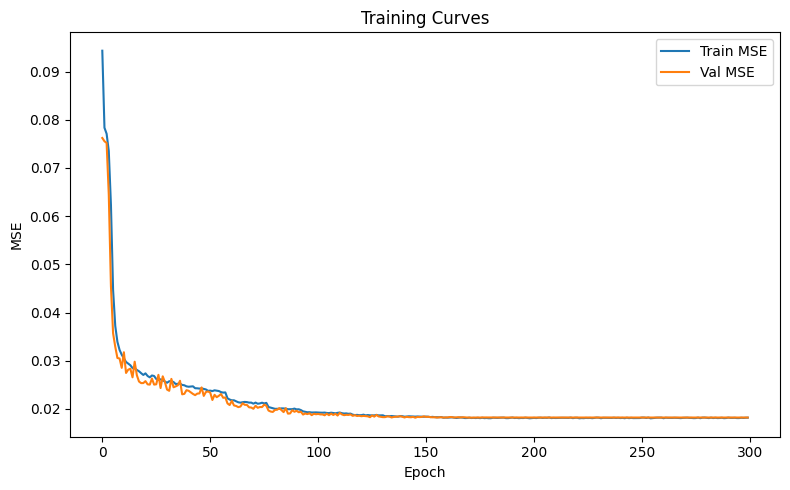

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Train MSE")
plt.plot(val_loss_history, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curves")
plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [51]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "best_val_loss": best_val_loss,
        "best_params": best_params,
        "best_mix_str_list": best_mix_str_list,
        "tabular_dim": tabular_train.shape[1],
    },
    os.path.join(TUNING_DIR, "best_model_full.pth"),
)
print(f"Model checkpoint saved to {TUNING_DIR}/best_model_full.pth")

Model checkpoint saved to nn_output/tuning/best_model_full.pth


In [37]:
def run_evaluation(dataloader, model, save_path):
    """
    Run inference on a DataLoader, compute metrics, save results and plots.

    Parameters
    ----------
    dataloader : DataLoader
        Yields batches of (E1, E2, X1, X2, tabular, y).
    model : nn.Module
        Trained model to evaluate.
    save_path : str
        Directory where plots and JSON result files will be saved.

    Returns
    -------
    preds_dict : dict
        {"y_true": [...], "y_pred": [...]}
    metrics_dict : dict
        {"MAE": ..., "MSE": ..., "R2": ..., "Kendall_tau": ...}
    """
    os.makedirs(save_path, exist_ok=True)

    device = next(model.parameters()).device
    model.eval()

    all_preds, all_targets = [], []
    with torch.no_grad():
        for E1, E2, X1, X2, tab, y in dataloader:
            E1, E2, X1, X2, tab = (
                E1.to(device),
                E2.to(device),
                X1.to(device),
                X2.to(device),
                tab.to(device),
            )
            preds = model(E1, E2, X1, X2, tab).cpu().numpy().flatten()
            all_preds.append(preds)
            all_targets.append(y.numpy().flatten())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    # Compute metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    tau = kendalltau(y_true, y_pred).correlation

    metrics_dict = {
        "MAE": float(mae),
        "MSE": float(mse),
        "R2": float(r2),
        "Kendall_tau": float(tau),
    }
    preds_dict = {
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
    }

    print(f"MAE         = {mae:.4f}")
    print(f"MSE         = {mse:.4f}")
    print(f"R²          = {r2:.4f}")
    print(f"Kendall's τ = {tau:.4f}")

    # Actual vs Predicted scatter plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.1, s=10)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", label="Perfect fit")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title("Actual vs Predicted")
    ax.legend()
    scatter_path = os.path.join(save_path, "actual_vs_predicted.png")
    fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Scatter plot saved to {scatter_path}")

    # Distribution histogram: true vs predicted
    fig, ax = plt.subplots(figsize=(7, 5))
    bins = np.linspace(
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max()),
        50,
    )
    ax.hist(
        y_true, bins=bins, alpha=0.6, label="True", color="steelblue", edgecolor="none"
    )
    ax.hist(
        y_pred,
        bins=bins,
        alpha=0.6,
        label="Predicted",
        color="darkorange",
        edgecolor="none",
    )
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.set_title("Distribution: True vs Predicted")
    ax.legend()
    hist_path = os.path.join(save_path, "distribution_histogram.png")
    fig.savefig(hist_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Histogram saved to {hist_path}")

    # Save both dicts as JSON
    preds_path = os.path.join(save_path, "predictions.json")
    metrics_path = os.path.join(save_path, "metrics.json")
    with open(preds_path, "w") as f:
        json.dump(preds_dict, f)
    with open(metrics_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)
    print(f"Predictions saved to {preds_path}")
    print(f"Metrics saved to     {metrics_path}")

    return preds_dict, metrics_dict

In [43]:
# Load architecture params from tuning_results.json
with open(os.path.join(TUNING_DIR, "tuning_results.json"), "r") as _f:
    _tuning = json.load(_f)
best_params = _tuning["best_params"]
best_mix_str_list = _tuning["best_mix_str_list"]

# Load model weights from best_model_full.pth
_ckpt = torch.load(
    os.path.join(TUNING_DIR, "best_model_full.pth"),
    map_location=device,
    weights_only=False,
)

best_model = MultiModalNet(
    smiles_dim=512,
    rdkit_dim=200,
    rdkit_embed_dim=best_params["rdkit_embed_dim"],
    tabular_dim=_ckpt["tabular_dim"],
    fusion_dim=best_params["fusion_dim"],
    hidden_dim=best_params["hidden_dim"],
    n_predictor_layers=best_params["n_predictor_layers"],
    dropout=best_params["dropout"],
).to(device)
best_model.smiles_fusion = MixtureFusion(
    best_params["fusion_dim"], mix_str_list=best_mix_str_list
).to(device)
best_model.rdkit_fusion = MixtureFusion(
    best_params["rdkit_embed_dim"], mix_str_list=best_mix_str_list
).to(device)
best_model.load_state_dict(_ckpt["model_state_dict"])
best_model.eval()
print(f"Loaded best model | best_val_loss: {_ckpt['best_val_loss']:.4f}")
print(
    f"Architecture: hidden_dim={best_params['hidden_dim']}, n_predictor_layers={best_params['n_predictor_layers']}, mix={best_mix_str_list}"
)

Loaded best model | best_val_loss: 0.0182
Architecture: hidden_dim=256, n_predictor_layers=3, mix=['prod', 'cos']


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MultiModalNet                            [512, 512]                [512, 1]                  --                        True
├─Linear: 1-1                            [512, 512]                [512, 128]                65,664                    True
├─Linear: 1-2                            [512, 512]                [512, 128]                (recursive)               True
├─MixtureFusion: 1-3                     [512, 128]                [512, 128]                --                        True
│    └─Linear: 2-1                       [512, 129]                [512, 128]                16,640                    True
├─RDKitEncoder: 1-4                      [512, 200]                [512, 128]                --                        True
│    └─Sequential: 2-2                   [512, 200]                [512, 128]                --                        True
│  

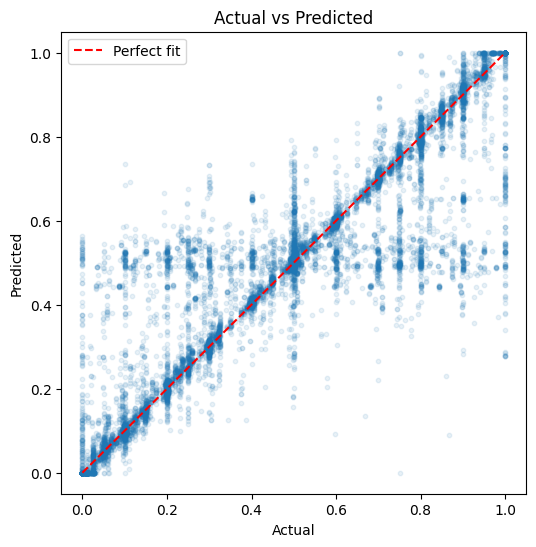

Scatter plot saved to ./nn_output/results/validation\actual_vs_predicted.png


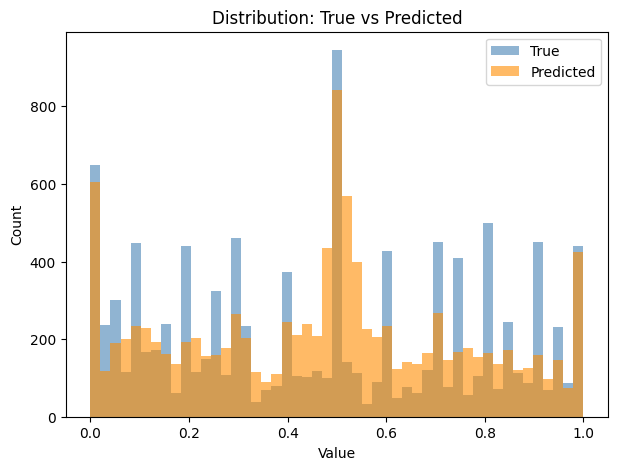

Histogram saved to ./nn_output/results/validation\distribution_histogram.png
Predictions saved to ./nn_output/results/validation\predictions.json
Metrics saved to     ./nn_output/results/validation\metrics.json


In [47]:
from torchinfo import summary as torchinfo_summary

# Model summary for best_model
_sample_batch = next(iter(val_loader))
_E1, _E2, _X1, _X2, _tab, _ = [
    t.to(next(best_model.parameters()).device) for t in _sample_batch
]
torchinfo_summary(
    best_model,
    input_data=[_E1, _E2, _X1, _X2, _tab],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4,
    verbose=1,
)

pred, metrics = run_evaluation(
    val_loader, model=best_model, save_path="./nn_output/results/validation"
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MultiModalNet                            [512, 512]                [512, 1]                  --                        True
├─Linear: 1-1                            [512, 512]                [512, 128]                65,664                    True
├─Linear: 1-2                            [512, 512]                [512, 128]                (recursive)               True
├─MixtureFusion: 1-3                     [512, 128]                [512, 128]                --                        True
│    └─Linear: 2-1                       [512, 129]                [512, 128]                16,640                    True
├─RDKitEncoder: 1-4                      [512, 200]                [512, 128]                --                        True
│    └─Sequential: 2-2                   [512, 200]                [512, 128]                --                        True
│  

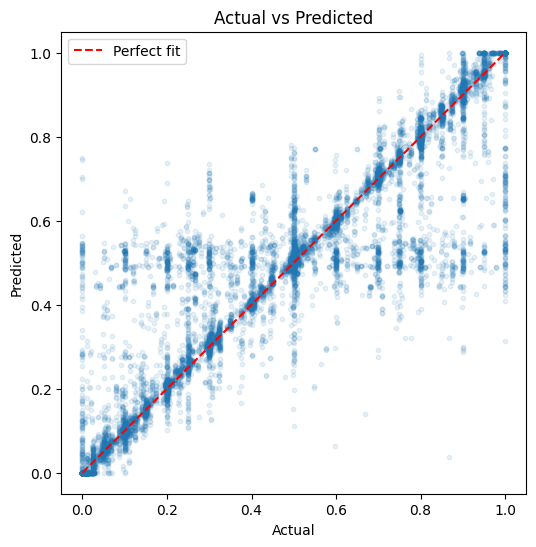

Scatter plot saved to nn_output/tuning\eval_test\actual_vs_predicted.png


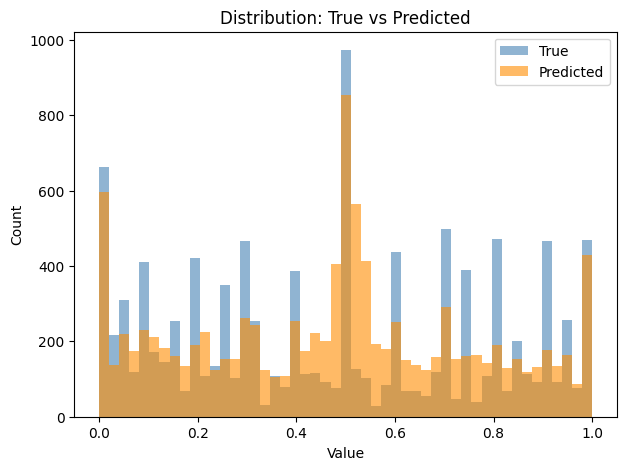

Histogram saved to nn_output/tuning\eval_test\distribution_histogram.png
Predictions saved to nn_output/tuning\eval_test\predictions.json
Metrics saved to     nn_output/tuning\eval_test\metrics.json


In [48]:
# Build test DataLoader
test_dataset = MultiModalDataset(
    E1_test, E2_test, X1_test, X2_test, tabular_test, y_test
)
test_loader = DataLoader(test_dataset, batch_size=512)

from torchinfo import summary as torchinfo_summary

# Model summary
_sample_batch = next(iter(test_loader))
_E1, _E2, _X1, _X2, _tab, _ = [
    t.to(next(best_model.parameters()).device) for t in _sample_batch
]
torchinfo_summary(
    best_model,
    input_data=[_E1, _E2, _X1, _X2, _tab],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4,
    verbose=1,
)

pred_test, metrics_test = run_evaluation(
    test_loader,
    model=best_model,
    save_path=os.path.join(TUNING_DIR, "eval_test"),
)

In [57]:
def evaluate_model(
    y_test,
    y_pred,
    show_plot=False,
    save_file=False,
    save_path="./results.json",
    n_bootstrap=1000,
):
    """Evaluate model performance with bootstrap 95% CI (mu +/- 1.96*std)."""
    y_test = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    # Point estimates
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap on test set
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    # mu, std, and 95% CI from bootstrap distribution
    def ci95(scores):
        mu = np.mean(scores)
        std = np.std(scores, ddof=1)
        return mu, std, mu - 1.96 * std, mu + 1.96 * std

    mae_mu, mae_std, mae_lo, mae_hi = ci95(mae_scores)
    mse_mu, mse_std, mse_lo, mse_hi = ci95(mse_scores)
    r2_mu, r2_std, r2_lo, r2_hi = ci95(r2_scores)
    tau_mu, tau_std, tau_lo, tau_hi = ci95(tau_scores)

    print(
        f"MAE         = {mae:.4f}  |  bootstrap mu={mae_mu:.4f}, std={mae_std:.4f}  (95% CI: {mae_lo:.4f} – {mae_hi:.4f})"
    )
    print(
        f"MSE         = {mse:.4f}  |  bootstrap mu={mse_mu:.4f}, std={mse_std:.4f}  (95% CI: {mse_lo:.4f} – {mse_hi:.4f})"
    )
    print(
        f"R²          = {r2:.4f}  |  bootstrap mu={r2_mu:.4f}, std={r2_std:.4f}  (95% CI: {r2_lo:.4f} – {r2_hi:.4f})"
    )
    print(
        f"Kendall’s τ  = {tau:.4f}  |  bootstrap mu={tau_mu:.4f}, std={tau_std:.4f}  (95% CI: {tau_lo:.4f} – {tau_hi:.4f})"
    )

    results = {
        "MAE": {
            "value": mae,
            "bootstrap_mu": mae_mu,
            "bootstrap_std": mae_std,
            "ci95_lo": mae_lo,
            "ci95_hi": mae_hi,
        },
        "MSE": {
            "value": mse,
            "bootstrap_mu": mse_mu,
            "bootstrap_std": mse_std,
            "ci95_lo": mse_lo,
            "ci95_hi": mse_hi,
        },
        "R2": {
            "value": r2,
            "bootstrap_mu": r2_mu,
            "bootstrap_std": r2_std,
            "ci95_lo": r2_lo,
            "ci95_hi": r2_hi,
        },
        "Kendall_tau": {
            "value": tau,
            "bootstrap_mu": tau_mu,
            "bootstrap_std": tau_std,
            "ci95_lo": tau_lo,
            "ci95_hi": tau_hi,
        },
    }

    if save_file:
        with open(save_path, "w") as f:
            json.dump(results, f, indent=2)
        print(f"Results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s=10)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            "r--",
            label="Perfect fit",
        )
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted")
        plt.legend()
        plt.show()

    return results

MAE         = 0.0696  |  bootstrap mu=0.0696, std=0.0011  (95% CI: 0.0675 – 0.0717)
MSE         = 0.0174  |  bootstrap mu=0.0174, std=0.0005  (95% CI: 0.0165 – 0.0183)
R²          = 0.8175  |  bootstrap mu=0.8175, std=0.0047  (95% CI: 0.8082 – 0.8268)
Kendall’s τ  = 0.7680  |  bootstrap mu=0.7680, std=0.0038  (95% CI: 0.7604 – 0.7755)
Results saved to nn_output/tuning\eval_test\bootstrap_metrics.json


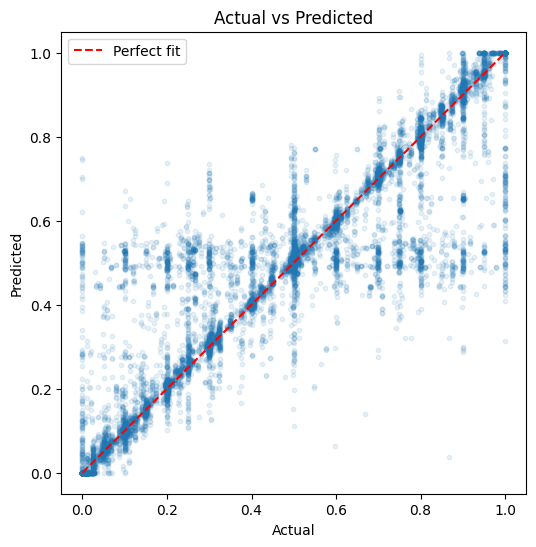

In [60]:
results_test = evaluate_model(
    pred_test["y_true"],
    pred_test["y_pred"],
    show_plot=True,
    save_file=True,
    save_path=os.path.join(TUNING_DIR, "eval_test", "bootstrap_metrics.json"),
)

Loaded model | best_val_loss: 0.0182
Architecture: hidden_dim=256, n_predictor_layers=3, mix=['prod', 'cos']
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MultiModalNet                            [512, 512]                [512, 1]                  --                        True
├─Linear: 1-1                            [512, 512]                [512, 128]                65,664                    True
├─Linear: 1-2                            [512, 512]                [512, 128]                (recursive)               True
├─MixtureFusion: 1-3                     [512, 128]                [512, 128]                --                        True
│    └─Linear: 2-1                       [512, 129]                [512, 128]                16,640                    True
├─RDKitEncoder: 1-4                      [512, 200]                [512, 128]                --                        True
│    └─Sequential:

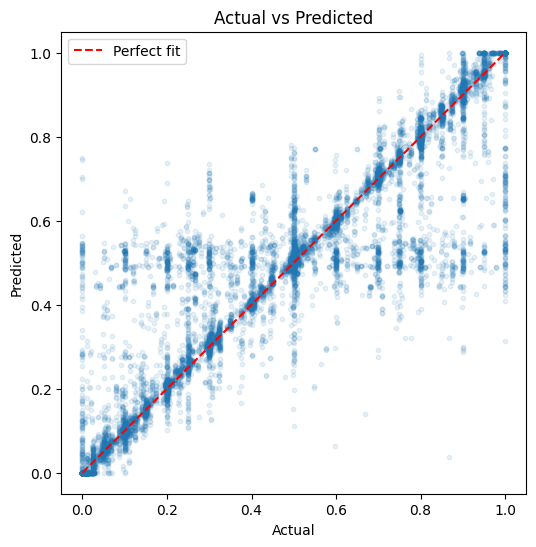

Scatter plot saved to nn_output/tuning\eval_loaded\actual_vs_predicted.png


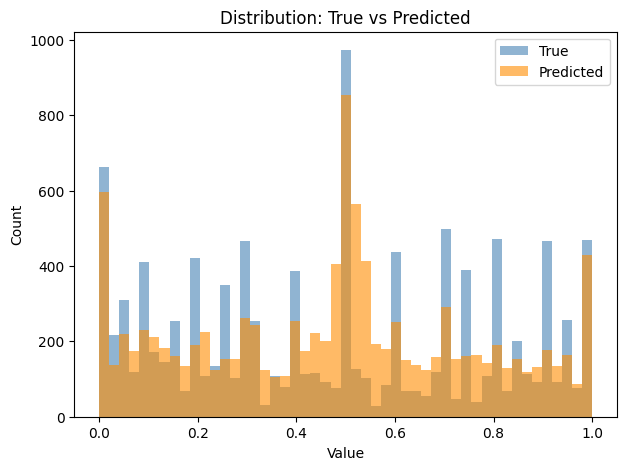

Histogram saved to nn_output/tuning\eval_loaded\distribution_histogram.png
Predictions saved to nn_output/tuning\eval_loaded\predictions.json
Metrics saved to     nn_output/tuning\eval_loaded\metrics.json


In [61]:
# Load model from saved checkpoint (can be run independently)
_ckpt = torch.load(
    os.path.join(TUNING_DIR, "best_model_full.pth"),
    map_location=device,
    weights_only=False,
)
_bp = _ckpt["best_params"]
_mix = _ckpt["best_mix_str_list"]

loaded_model = MultiModalNet(
    smiles_dim=512,
    rdkit_dim=200,
    rdkit_embed_dim=_bp["rdkit_embed_dim"],
    tabular_dim=_ckpt["tabular_dim"],
    fusion_dim=_bp["fusion_dim"],
    hidden_dim=_bp["hidden_dim"],
    n_predictor_layers=_bp["n_predictor_layers"],
    dropout=_bp["dropout"],
).to(device)
loaded_model.smiles_fusion = MixtureFusion(_bp["fusion_dim"], mix_str_list=_mix).to(
    device
)
loaded_model.rdkit_fusion = MixtureFusion(_bp["rdkit_embed_dim"], mix_str_list=_mix).to(
    device
)
loaded_model.load_state_dict(_ckpt["model_state_dict"])
loaded_model.eval()
print(f"Loaded model | best_val_loss: {_ckpt['best_val_loss']:.4f}")
print(
    f"Architecture: hidden_dim={_bp['hidden_dim']}, n_predictor_layers={_bp['n_predictor_layers']}, mix={_mix}"
)

from torchinfo import summary as torchinfo_summary

_sample_batch = next(iter(test_loader))
_E1, _E2, _X1, _X2, _tab, _ = [t.to(device) for t in _sample_batch]
torchinfo_summary(
    loaded_model,
    input_data=[_E1, _E2, _X1, _X2, _tab],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4,
    verbose=1,
)

pred_loaded, metrics_loaded = run_evaluation(
    test_loader,
    model=loaded_model,
    save_path=os.path.join(TUNING_DIR, "eval_loaded"),
)

In [59]:
import shutil

# List of files to save
files_to_save = ["multimodal.pth", "training_curves.png"]

# Copy each file to your specified Google Drive folder
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder_path, f))
        print(f"Saved {f} to {folder_path}")
    else:
        print(f"File {f} not found in local storage.")

Saved multimodal.pth to ./processed_data
Saved training_curves.png to ./processed_data


In [21]:
# Print best hyperparameters (no weights loaded)
TUNING_DIR = "nn_output/tuning"

# Primary source: tuning_results.json (Optuna output)
json_path = os.path.join(TUNING_DIR, "tuning_results.json")
if os.path.exists(json_path):
    with open(json_path) as _f:
        _tuning = json.load(_f)
    best_params = _tuning["best_params"]
    best_mix = _tuning.get("best_mix_str_list", [])
    best_val_loss = _tuning.get("best_value", None)
    print("Source: tuning_results.json")
else:
    # Fallback: read params embedded in the checkpoint (no model built)
    import torch

    _ckpt = torch.load(
        os.path.join(TUNING_DIR, "best_model_full.pth"),
        map_location="cpu",
        weights_only=False,
    )
    best_params = _ckpt["best_params"]
    best_mix = _ckpt.get("best_mix_str_list", [])
    best_val_loss = _ckpt.get("best_val_loss", None)
    print("Source: best_model_full.pth (checkpoint metadata only)")

print("=== Best Hyperparameters ===")
for k, v in best_params.items():
    print(f"  {k:25s}: {v}")
key_mix = "best_mix_str_list"
print(f"  {key_mix:25s}: {best_mix}")
if best_val_loss is not None:
    key_loss = "best_val_loss"
    print(f"  {key_loss:25s}: {best_val_loss:.6f}")

Source: tuning_results.json
=== Best Hyperparameters ===
  lr                       : 0.0007360227545321503
  dropout                  : 0.17058137159729952
  hidden_dim               : 256
  n_predictor_layers       : 3
  rdkit_embed_dim          : 128
  fusion_dim               : 128
  mix_origin               : False
  mix_prod                 : True
  mix_sum                  : False
  mix_cos                  : True
  best_mix_str_list        : ['prod', 'cos']
  best_val_loss            : 0.020213
